<a href="https://colab.research.google.com/github/antonidesjardins15/Capstone_Project/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Library



In [2]:
# Library Python
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(f1_score, accuracy_score, recall_score)
from sklearn.metrics import classification_report

## Load Data
Load the MedicalAppointment_NoShows dataset into pandas DataFrame

In [3]:
#1 File upload
from google.colab import files
uploaded = files.upload()

Saving MedicalAppointment_NoShows.csv to MedicalAppointment_NoShows.csv


In [4]:
# load datasat
df = pd.read_csv('MedicalAppointment_NoShows.csv')


print("The first 5 rows of DataSets 'MedicalAppointment_NoShows.':")
print("Shape", df.shape)
df.head()

The first 5 rows of DataSets 'MedicalAppointment_NoShows.':
Shape (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No




---


# 1) Pandas inspection (types, missing values, duplicates)


---



In [5]:
# information of the dataset before cleaning
df.info()

# Verification of Missing Values
na_count = df.isna().sum().sort_values(ascending=False) # Count and classify missing (empty) values in each column
print("\nMissing values in each column:")
print(na_count) # Ouutput = no missing values

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB

Missing values in each column:
PatientId         0
AppointmentID     0
Gender            

## Data target (no-show) verification

In [6]:
# Verification of different values in the target column 'no-show'
df['No-show'].unique() # make sure that the no-show column has only two possible variables

array(['No', 'Yes'], dtype=object)



---

# 2) Data Processing — Cleaning




---



## Correct Column Names

Objective: Standardize names to facilitate manipulation and avoid typos.

In [7]:
# Dataset typo corrections

# First, normalize all column names to lowercase and replace hyphens with underscores
df.columns = df.columns.str.lower().str.replace('-', '_')

# '.rename' of Pandas  to correct typos in column titles
df.rename(columns={'hipertension': 'hypertension',
    'handcap': 'handicap',
    'neighbourhood': 'neighborhood',
    'scheduledday': 'scheduled_day',
    'appointmentday': 'appointment_day',
    'patientid': 'patient_id',
    'appointmentid': 'appointment_id',
    'no-show': 'no_show'}, inplace=True)

print(f"Columns names updated:")
df.head()

Columns names updated:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### Correction of Date columns (data type/formats)

Convert character strings into datetime objects to enable temporal operations (calculation of time periods, extraction of calendar characteristics)

Objective: Make date columns usable for feature engineering.



In [8]:
# Correct data type/format

# Convert to datetime with 'UTC time zone' management
# Remove time zone info for display ‘(tz_localize(None))’
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'], utc=True).dt.tz_localize(None)
# For AppointmentDay, do the same thing + normalize() to set the time to 00:00:00 and remove the time zone info
df['appointment_day'] = pd.to_datetime(df['appointment_day']).dt.normalize().dt.tz_localize(None)

# Check
print("Data types after conversion:")
df.info()
df.head()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   patient_id       110527 non-null  float64       
 1   appointment_id   110527 non-null  int64         
 2   gender           110527 non-null  object        
 3   scheduled_day    110527 non-null  datetime64[ns]
 4   appointment_day  110527 non-null  datetime64[ns]
 5   age              110527 non-null  int64         
 6   neighborhood     110527 non-null  object        
 7   scholarship      110527 non-null  int64         
 8   hypertension     110527 non-null  int64         
 9   diabetes         110527 non-null  int64         
 10  alcoholism       110527 non-null  int64         
 11  handicap         110527 non-null  int64         
 12  sms_received     110527 non-null  int64         
 13  no_show          110527 non-null  object     

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29 16:08:27,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29 16:19:04,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29 17:29:31,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29 16:07:23,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### Handle Aberrant Ages

Remove rows where the age is illogical (less than 0 or greater than 100).

Objective: Eliminate erroneous data that could skew the analysis or model training

In [9]:
# Cleaning aberrant values

# Age: ensure that age data is biologically plausible
if 'age' in df.columns: # clean aberrant values
    before_clean_age = len(df) # To obtain the number of rows before cleaning ages
    df = df[(df['age'] >= 0) & (df['age'] <= 100)].copy() #  2 Conditions: Deletes negative age errors and Deletes extreme values (100 advanced)
    after_clean_age = len(df)

    print(f"deleted rows for aberrant ages: {before_clean_age - after_clean_age}")

deleted rows for aberrant ages: 8


### Remove Inconsistent Appointments

Remove appointments where appointment_day is earlier than scheduled_day, which is logically impossible.

The AppointmentDay and ScheduledDay columns were previously converted to datetime objects without time zones. Therefore, the difference in days is calculated without taking into account any time differences, as this information has been removed.

Objective: Ensure temporal consistency of data.

In [10]:
# cleaning illogical appointments
initial_rows = df.shape[0] # Records the initial number of rows before cleaning
df['lead_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days #  new column ‘lead_time’ created for the “mask borleen”. Calculates the difference between 'appointment_id' and 'scheduled_day'
                                                                        #  “.dt.days” Extracts the number (integer) of days after subtraction due to the timedelta object

# # Filters the DataFrame to keep only “lead_days” greater than or equal to 0.
df = df[df['lead_days'] >= 0].copy() # “df['lead_days”] >= 0" to create a Boolean mask (True/False) where True indicates a valid result (logical date), and False for errors
                                      # 'lead_days = delay between scheduling and appointment
                                      # '.copy()' creates a new DataFrame with only valid rows
final_rows = df.shape[0] #  records the number of rows remaining in the DataFrame df after cleaning

print(f"Removed {initial_rows - final_rows} rows with inconsistent scheduling.") # Displays the number of rows that were removed
print("DataFrame after removing inconsistent appointments:")
df.head()

Removed 38565 rows with inconsistent scheduling.
DataFrame after removing inconsistent appointments:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,lead_days
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,0,0,0,No,1
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,0,0,0,No,1
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,0,0,0,No,1


### Convert Target Variable

Convert the 'No-show' column into a binary format: 'Yes' = 1 (representing a no-show) and 'No' = 0 (representing a show), making the target variable suitable for machine learning models.

Objective: Prepare the no_show variable for model training.


In [11]:
# Change the format of the target variable 'no_show'
df['no_show'] = df['no_show'].apply(lambda x: 1 if x == 'Yes' else 0).astype(int) # ‘.apply()’ to scan each row of the ‘no_show’ column
                                                                                  # # ‘lamba’ to check if the value x is ‘YES’ to change it to 1. Else, it returns to 0
# Analysis of Class Distribution (no-show)
print("Number of 'no_show' after conversion:")
print(df['no_show'].value_counts())

df.head()

Number of 'no_show' after conversion:
no_show
0    51435
1    20519
Name: count, dtype: int64


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,lead_days
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,0,0,0,0,1
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,0,0,0,1,1
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,0,0,0,1,1
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,0,0,0,0,1
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,0,0,0,0,1


### Proportion of no-shows




In [12]:
#  calculation of the proportion of no-shows
df['no_show'].sum() / len(df) # in the ‘no_show’ colum, it counts the number of 'no-shows' or 1 (boolean values)
                               # '/ len(df)' : to divide by the total number of rows in the dataset

np.float64(0.28516830197070353)



---



# 3) Data manipulation/engineering



---



### Create Delay Features

Engineer new features to capture the delay between scheduling and appointment. creation des fonctionnalie pour saisir le délai entre la prise de rendez-vous et le rendez-vous. Le AI me propose ces themes : lead_days (delay in days), 'lead_hours' (delay in hours), and 'is_same_day' (a boolean indicating if the appointment is on the same day it was scheduled). I want confirmation if a patient is more likely to miss their appointment based on the level of urgency.

**lead_day**:Calculates the number of days between the appointment scheduling date (scheduled_day) and the appointment date (appointment_day)..

**lead_hours** : Same principle as lead_days, but calculates the delay in hours.

**is_same_day** : Binary variable (True/False) indicating whether the appointment is to take place on the same day (lead_days = 0).


In [13]:
# Creation of new functions
# Creation of ‘lead_hours’ (result in timedelta)
df['lead_hours'] = (df['appointment_day'] - df['scheduled_day']).dt.total_seconds() / 3600 # '.dt.total_seconds()': Converts results into seconds for calculations

# Creation of 'is_same_day'
df['is_same_day'] = (df['lead_days'] == 0) # Creation of a Boolean variable (True or False).
                                            # From ‘lead_day’, True = appointment made on the same day. False = appointment was made at least one day in advance
print("Delay features 'lead_hours' and 'is_same_day' created:")
df.head()

Delay features 'lead_hours' and 'is_same_day' created:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,lead_days,lead_hours,is_same_day
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,0,0,0,0,1,39.385833,False
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,0,0,0,1,1,32.913333,False
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,0,0,0,1,1,32.333889,False
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,0,0,0,0,1,35.193056,False
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,0,0,0,0,1,33.030278,False


### Extract Calendar Features

Extract the features (Datetime) related to the 'scheduled_day' and 'appointment_day' columns using '.dt' from pandas to create new columns of temporal features (day of the week, month, and scheduled time).

This step breaks down a complete date into numerical information so that calculations can be made and the probability of a patient showing up or not can be analyzed.

**scheduled_day_of_week and appointment_day_of_week (Day of the week**): Extract the day of the week (Monday=0, Sunday=6) when the appointment was made and when it is scheduled to take place. Certain days of the week may be more prone to no-shows.

**scheduled_month and appointment_month (Month)**: Extracts the month in which the appointment was made and held. Can be used to identify seasonal trends.

scheduled_hour (Appointment time): Extracts the time at which the appointment was scheduled.




In [14]:
# '.dt.dayofweek' for extracting the day of the week
# Extracts the day of the week as an integer (e.g., Monday = 0, Tuesday = 1). Allows you to determine no-show trends based on the day the appointment was made
df['scheduled_day_of_week'] = df['scheduled_day'].dt.dayofweek
df['appointment_day_of_week'] = df['appointment_day'].dt.dayofweek

# 'dt.month' to extract the month
# Extracts the month number (1 to 12). Allows you to detect seasonal trends
df['scheduled_month'] = df['scheduled_day'].dt.month
df['appointment_month'] = df['appointment_day'].dt.month

# 'dt.hou' for extracting the hour
# Extracts the hour of the day when the appointment was made (0 to 23). Allows you to detect trends based on the time of day when the appointment was mades
df['scheduled_hour'] = df['scheduled_day'].dt.hour

print("Calendar features 'scheduled_day_of_week', 'appointment_day_of_week', 'scheduled_month', 'appointment_month', and 'scheduled_hour' created:")
df.head()

Calendar features 'scheduled_day_of_week', 'appointment_day_of_week', 'scheduled_month', 'appointment_month', and 'scheduled_hour' created:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,...,sms_received,no_show,lead_days,lead_hours,is_same_day,scheduled_day_of_week,appointment_day_of_week,scheduled_month,appointment_month,scheduled_hour
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,...,0,0,1,39.385833,False,2,4,4,4,8
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,...,0,1,1,32.913333,False,2,4,4,4,15
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,...,0,1,1,32.333889,False,2,4,4,4,15
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,...,0,0,1,35.193056,False,2,4,4,4,12
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,...,0,0,1,33.030278,False,2,4,4,4,14


### Patient Geographic Features

The purpose of this step is to capture Geographic Influence to determine whether the neighborhood where a patient lives may be a factor influencing the likelihood of a patient showing up for their appointment (e.g., remote area). By then calculating the average no-show rate per neighborhood, we aggregate information about the behavior of the local population.

**neigh_no_show_rate (Average neighborhood no-show rate)** : Represents the average no-show rate for the patient's neighborhood.



In [15]:
neigh_no_show_rate = df.groupby('neighborhood')['no_show'].mean()
df['neigh_no_show_rate'] = df['neighborhood'].map(neigh_no_show_rate)

print("Neighborhood no-show rate ('neigh_no_show_rate') created:")
df.head()

Neighborhood no-show rate ('neigh_no_show_rate') created:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,...,no_show,lead_days,lead_hours,is_same_day,scheduled_day_of_week,appointment_day_of_week,scheduled_month,appointment_month,scheduled_hour,neigh_no_show_rate
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,...,0,1,39.385833,False,2,4,4,4,8,0.229730
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,...,1,1,32.913333,False,2,4,4,4,15,0.228893
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,...,1,1,32.333889,False,2,4,4,4,15,0.228893
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,...,0,1,35.193056,False,2,4,4,4,12,0.298729
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,...,0,1,33.030278,False,2,4,4,4,14,0.290051


### Patient profile features - 60 years old or more, genre, age_bucket, num_chronic_disease

Creation of columns with patient characteristics. This will simplify patient profile information and facilitate statistical comparison. The goal is to see if these patient characteristics can also influence no-shows.

**is_male (gender)** : Binary variable (1 if male, 0 if female).

**is_old** : Binary variable (1 if the patient is 60 years old or older, 0 otherwise).

**age_bucket (age group)** : Catégorise l'âge en groupes (ex: 0-17, 18-30, etc.). Enables the capture of non-linear relationships between age and no-shows.

**chronic_count (Number of chronic diseases)** : Counts the number of chronic diseases (hypertension, diabetes, alcoholism, disability) for each patient. Is someone in good health (0 chronic diseases) more likely to forget their appointment?

In [16]:
# gender
df['is_male'] = np.where(df['gender'] == 'M', 1, 0) # 1 = Male, 0 = Female

# Old or not
df['is_old'] = np.where(df['age'] >= 60, 1, 0) # If the patient is 60 or older = 1, otherwise = 0

# Grouping by age range (age_bucket)
bins = [0, 17, 30, 50, 64, df['age'].max()] # 'bins' for group creation (0 to 17, 18 to 30, etc.). .max() for the highest age
labels = ['0-17', '18-30', '31-50', '51-64', '65+'] # 'labels’ to create a name for these groups
df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Determination of overall health per patient (number of chronic diseases per patient)
df['chronic_count'] = df['hypertension'] + df['diabetes'] + df['alcoholism'] + df['handicap'] # E.g. If a patient has 'Hypertension' + 'Diabetes' = 2

print("Patient profile features 'age_bucket' and 'chronic_count' created:")
df.head()

print("Patient profile features 'is_male' and 'is_old' created:")
df.head()

Patient profile features 'age_bucket' and 'chronic_count' created:
Patient profile features 'is_male' and 'is_old' created:


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighborhood,scholarship,hypertension,diabetes,...,scheduled_day_of_week,appointment_day_of_week,scheduled_month,appointment_month,scheduled_hour,neigh_no_show_rate,is_male,is_old,age_bucket,chronic_count
5,9.598510e+13,5626772,F,2016-04-27 08:36:51,2016-04-29,76,REPÚBLICA,0,1,0,...,2,4,4,4,8,0.229730,0,1,65+,1
6,7.336880e+14,5630279,F,2016-04-27 15:05:12,2016-04-29,23,GOIABEIRAS,0,0,0,...,2,4,4,4,15,0.228893,0,0,18-30,0
7,3.449830e+12,5630575,F,2016-04-27 15:39:58,2016-04-29,39,GOIABEIRAS,0,0,0,...,2,4,4,4,15,0.228893,0,0,31-50,0
9,7.812460e+13,5629123,F,2016-04-27 12:48:25,2016-04-29,19,CONQUISTA,0,0,0,...,2,4,4,4,12,0.298729,0,0,18-30,0
10,7.345360e+14,5630213,F,2016-04-27 14:58:11,2016-04-29,30,NOVA PALESTINA,0,0,0,...,2,4,4,4,14,0.290051,0,0,18-30,0


---

# 3) Data visualization

---



### *Correlation Analysis - Features and Target

Objective: Quickly identify the variables that most influence no-shows.


Corrélation de chaque caractéristique avec 'no_show' (triée):


,no_show
neigh_no_show_rate,0.083812
lead_days,0.060363
lead_hours,0.060117
scholarship,0.045706
scheduled_hour,0.030739
is_male,0.002328
scheduled_day_of_week,-0.002125
appointment_day_of_week,-0.010080
sms_received,-0.020568
appointment_month,-0.026861


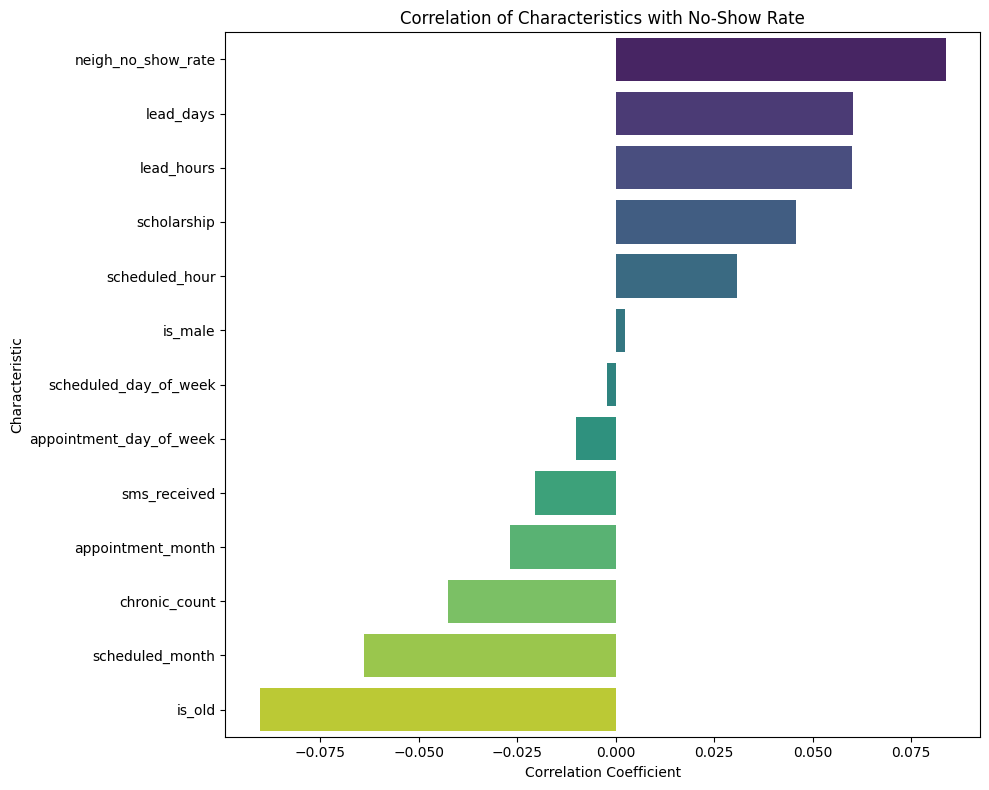

In [17]:
#Extract the names of all columns in the DataFrame that are numerical and that I consider relevant based on the graphs above, with the target variable (no_show)
features_for_target_corr = [
    'scholarship', 'sms_received', 'lead_days', 'lead_hours', 'scheduled_day_of_week',
    'appointment_day_of_week', 'scheduled_hour',
    'scheduled_month', 'appointment_month', 'neigh_no_show_rate',
    'chronic_count', 'is_male', 'is_old',
    'no_show']

# Calculate the complete correlation matrix according to the selected columns
correlation_matrix = df[features_for_target_corr].corr()

# Extract correlations with 'no_show'
no_show_correlations = correlation_matrix['no_show'].sort_values(ascending=False)

# Exclude the correlation of ‘no_show’ (unnecessary)
no_show_correlations = no_show_correlations.drop('no_show')

print("Corrélation de chaque caractéristique avec 'no_show' (triée):")
display(no_show_correlations)

#  main correlations (barplot)
plt.figure(figsize=(10, 8))
sns.barplot(x=no_show_correlations.values, y=no_show_correlations.index, palette='viridis', hue=no_show_correlations.index, legend=False)
plt.title('Correlation of Characteristics with No-Show Rate')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Characteristic')
plt.tight_layout()
plt.show()

### Correlation rate by age group

Assessment of the influence of age group (age_bucket) on no-shows.

In [18]:
no_show_rate_by_age_bucket = df.groupby('age_bucket', observed=False)['no_show'].mean().sort_values(ascending=False)

print("Average No-Show Rate by Age Group:")
display(no_show_rate_by_age_bucket)

Average No-Show Rate by Age Group:


,no_show
age_bucket,
18-30,0.352996
0-17,0.322714
31-50,0.298584
51-64,0.224431
65+,0.208182


---

# 4) Machine Learning developpment

---



## Training machine learning model

For the development of a predictive model for no-shows (non-binary classification problem), I will use the 'RandomForestClassifier'. I think this would be useful since I have a mix of varied data (numerical and categorical). I also think that the 'RandomForestClassifier' is capable of discovering complex relationships between variables, and the behavior of a patient who does not show up.

### Train-Test Split

In [19]:
# *Identification of features that are not necessary for model training (avoid redundancy, and according to the graphs)
features_to_drop = [
    'patient_id',
    'appointment_id',
    'gender',
    'age',
    'neighborhood',
    'scheduled_day',
    'appointment_day',
    'is_male',
    'appointment_month',
    'hypertension', 'diabetes', 'alcoholism', 'handicap']

# Model training
# Separation of target and variables/features (X and y) for model training (use X to predict Y)
X = df.drop(columns=['no_show'] + features_to_drop) # Contains all the features we want to work with (applies the deletion list)
y = df['no_show'] # What we want to predict (whether the patient will show up)

# Split BEFORE any preprocessing - Divide the data into training sets
X_train, X_test, y_train, y_test = train_test_split(    #  Study this data to find correlations and then test them
      X, y, test_size=0.3, random_state=42) # 'test_size=0.3': 30% for testing and 70% for training (temporarily stored in a training set)

# Verification and Statistics
print(f"Training set: {X_train.shape} samples")
print(f"Test set: {X_test.shape} samples")

Training set: (50367, 13) samples
Test set: (21587, 13) samples


### Preprocessing



In [20]:
# Identify categorical and numerical features for the preprocessor
# Use X_train to ensures that the model structure is based solely on training data (avoid data leakage)
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist() #  Include 'category' for variables created with pd.cut
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist() # Select everything that looks like a number and put it in a list

# Create preprocessing steps for different column types
numeric_transformer = preprocessing.StandardScaler() # Standardization of numerical features (mean of 0, standard deviation of 1)
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False) #  Conversion of categorical features to a numerical format (binary columns)
                                                                                                    # drop='first': Avoid redundancy, 'sparse_output=False': data storage after transformation

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(      # List of transformations to apply
    transformers=[('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)],
    remainder='drop') # Drop any columns not listed in the transformers

# Get feature names after transformation
preprocessor.fit(X_train)  # Analyze 'X_train' to learn the transformation rules (StandardScaler and OneHotEncoder)
transformed_features = preprocessor.get_feature_names_out() # Retrieve the names of the transformed features


print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")
print(f"\nNew features name: {preprocessor.get_feature_names_out()}") # Call the method to display the new features name

Categorical features: ['age_bucket']
Numerical features: ['scholarship', 'sms_received', 'lead_days', 'lead_hours', 'scheduled_day_of_week', 'appointment_day_of_week', 'scheduled_month', 'scheduled_hour', 'neigh_no_show_rate', 'is_old', 'chronic_count']

New features name: ['num__scholarship' 'num__sms_received' 'num__lead_days' 'num__lead_hours'
 'num__scheduled_day_of_week' 'num__appointment_day_of_week'
 'num__scheduled_month' 'num__scheduled_hour' 'num__neigh_no_show_rate'
 'num__is_old' 'num__chronic_count' 'cat__age_bucket_18-30'
 'cat__age_bucket_31-50' 'cat__age_bucket_51-64' 'cat__age_bucket_65+']


### Automatic selection of the most relevant features

Install SelectKBest and f_classif

In [21]:
from sklearn.feature_selection import SelectKBest, f_classif  # 'SelectKBest': feature selection method
                                                              # 'f_classif': for a statistical scoring function
# Preparation of 'X_train_preprocessed' data
X_train_preprocessed = preprocessor.fit_transform(X_train) # transforms 'X_train' from the preprocessor already defined
feature_names = preprocessor.get_feature_names_out() # récupère les noms de toutes les caractéristiques après leur transformation par le preprocessor

# Apply SelectKBest to see statistical importance
# Choose a fixed number (e.g., k=10) or a percentage
selector = SelectKBest(score_func=f_classif, k=10) # 'f_classif' : to measure the strength of influence of each feature (selects the 10 best) with the target (no-show)
X_train_selected = selector.fit_transform(X_train_preprocessed, y_train) # 'X_train_selected' keeps only the 10 best features as requested

# Identification of retained columns
mask = selector.get_support()  # Boolean mask for sorting the selected features
selected_features_names = feature_names[mask]  # Retains only those features for which the corresponding Boolean is True

print(f"Number of initial variables (after encoding): {len(feature_names)}")
print(f"Number of retained variables: {len(selected_features_names)}")
print(f"Selected variables: {selected_features_names}")

Number of initial variables (after encoding): 15
Number of retained variables: 10
Selected variables: ['num__scholarship' 'num__lead_days' 'num__lead_hours'
 'num__scheduled_month' 'num__neigh_no_show_rate' 'num__is_old'
 'num__chronic_count' 'cat__age_bucket_18-30' 'cat__age_bucket_51-64'
 'cat__age_bucket_65+']


### Pipeline initial: Preprocessing + Training

In [22]:
# Create a pipeline with preprocessing and RandomForestClassifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),  # 'steps': list of tuples representing each step in the pipeline (preprocessor + classifier)
    ('classifier', RandomForestClassifier(random_state=42))]) # RandomForestClassifier (2nd step). Add parameter to give more weight to samples from the minority class (no-shows) during training


# Train the model/pipeline (model_pipeline)
model_pipeline.fit(X_train, y_train) # Presentation of training data

# Make a Prediction
y_pred = model_pipeline.predict(X_test) # Make a prediction with new data following training by applying each preprocessing step (preprocessor + classifier)
                                        # Prediction stored in the variable 'y_pred'


print(f"Model score (overall accuracy): {model_pipeline.score(X_test, y_test)}")
print(f"Model score (recall): {recall_score(y_test, y_pred)}")
print(f"Model score (f1): {f1_score(y_test, y_pred)}")

Model score (overall accuracy): 0.6986612312966137
Model score (recall): 0.21425077449861404
Model score (f1): 0.2877477280192708


---

# 5) Hyperparameter Tuning

---



## Installer Optuna

Install the Optuna library using pip

In [23]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.2 MB/s eta 0:00:00


### Importing Optuna into libraries

In [24]:
# Inclure Optuna
import optuna

### Divide the training data again with Validation set

This time, divide the data into training, validation, and test sets to train the model and evaluate its performance on unseen data. The validation set (X_val) is used during the hyperparameter optimization process (by Optuna).

Optuna will train the model on X_train and evaluate its performance on X_val at each trial, allowing Optuna to choose the best hyperparameters without "seeing" the final test set.

In [25]:
# Split into a training set and a validation set  to adjust its hyperparameters
# Split 70% training / 15% validation / 15% testing

# First split: Separate the test (15%) from the rest (85%)
# Stratify=y: Guarantees that the proportions of classes y (no-show) are kept equal
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y   # 85% temporarily stored in 'X_train_temp' and 'y_train_temp'
)

# Second split: Separate the Train (70% total) from the Validation (15% total). Work with the remaining 85% of data from the first split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.176, random_state=42, stratify=y_train_temp  # size=0.176: calculated to obtain a 15% validation set
)

# Verification of statistics
print(f"Training set: {X_train.shape} samples")
print(f"Validation set: {X_val.shape} samples")
print(f"Test set: {X_test.shape} samples")

Training set: (50395, 13) samples
Validation set: (10765, 13) samples
Test set: (10794, 13) samples


# 6) Install the imbalanced-learn library (SMOTE)

Install the **imbalanced-learn** library using pip. This library is essential for using SMOTE. The aim is to oversample in order to generate synthetic samples from the minority class (no-show).


In [26]:
!pip install imbalanced-learn

### Importing SMOTE into libraries


In [27]:
#  include the SMOTE library from imblearn.over_sampling and Pipeline from imblearn.pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

### Define an existing objective function to integrate SMOTE into the pipeline

This function will train a RandomForestClassifier model with the hyperparameters suggested by Optuna and SMOTE

In [28]:
# DEFINE FUNCTION OBJECTIVE

def objective(trial):      # with the help of AI to find the best parameters and ranges
    # Hyperparameters for RandomForestClassifier
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 10, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    # Hyperparameters for SMOTE
    smote_sampling_strategy = trial.suggest_float('smote_sampling_strategy', 0.5, 1.0) # optimal for datasets with 28% no-shows
    smote_k_neighbors = trial.suggest_int('smote_k_neighbors', 3, 10)

    # Create an ImbPipeline with preprocessing, SMOTE, and RandomForestClassifier
    model_pipeline = ImbPipeline(steps=[       # ImbPipeline : to ensure that SMOTE is only applied during training (fit)
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42,
                        sampling_strategy=smote_sampling_strategy,
                        k_neighbors=smote_k_neighbors)),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Train the model
    model_pipeline.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_val = model_pipeline.predict(X_val)

    # Evaluate the model using F1_score for the 'no-show' class (pos_label=1)
    score = f1_score(y_val, y_pred_val, pos_label=1)

    return score

### Run the Optuna study (n_trials=100) - Run the Optuna study (n_trials=100) WITH f1 score

Create an Optuna study and launch the optimization process to find the best hyperparameters. This involves specifying the optimization direction (maximize the F1 score) and the number of trials.

Launch Bayesian optimization with Optuna by executing the optimize method with n_trials=100. This will allow Optuna to find the best combination of hyperparameters for the RandomForestClassifier, based on the already defined objective function and attempting to maximize the F1-score.

This involves creating a study, running the optimization with the defined objective function for 100 trials, and then printing the results of the best trial. The next step is to execute the Optuna study to find the best hyperparameters.



In [29]:
# Study a set of trials (optimization) and retrieve the results
# direction=‘maximize’: we seek to maximize the F1 score
study = optuna.create_study(direction='maximize', study_name='random_forest_optimization', storage=None)
study.optimize(objective, n_trials=100)

print("Number of finished trials: ", len(study.trials))
print("Best trial:") #  Extract the best trial
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():    # This loop is for going through the dictionary of parameters
    print("    {}: {}".format(key, value))

[I 2026-03-12 19:23:45,125] A new study created in memory with name: random_forest_optimization
[I 2026-03-12 19:24:04,897] Trial 0 finished with value: 0.424012822380883 and parameters: {'n_estimators': 74, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'smote_sampling_strategy': 0.8632817686559213, 'smote_k_neighbors': 5}. Best is trial 0 with value: 0.424012822380883.
[I 2026-03-12 19:24:21,031] Trial 1 finished with value: 0.42474470919046914 and parameters: {'n_estimators': 94, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'smote_sampling_strategy': 0.8935642781567797, 'smote_k_neighbors': 5}. Best is trial 1 with value: 0.42474470919046914.
[I 2026-03-12 19:24:28,543] Trial 2 finished with value: 0.4371069182389937 and parameters: {'n_estimators': 71, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'smote_sampling_strategy': 0.6382862407022929, 'smote_k_neigh

Number of finished trials:  100
Best trial:
  Value: 0.44699367088607594
  Params: 
    n_estimators: 60
    max_depth: 11
    min_samples_split: 2
    min_samples_leaf: 2
    max_features: log2
    smote_sampling_strategy: 0.5131459964052595
    smote_k_neighbors: 8


### Optimization history (F1 score per trial)

In [30]:
import optuna.visualization as ov

# Optimization history (f1 score per trial)
fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title='Optimization history (RandomForest)')
fig_history

In [31]:
# Importance of hyperparameters f1 score
fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Importance of hyperparameters (RandomForest - F1 score optimization)')
fig_importance

### Create and train the **final model** with the **best hyperparameters** and **SMOTE**

Create the final classification model pipeline using the best hyperparameters found by Optuna, including SMOTE, and train it on the combined training and validation datasets.

In [32]:
#  Extract the best hyperparameters from the Optuna study
best_params = study.best_trial.params

#  Create the final model pipeline with the best hyperparameters, including SMOTE
best_model_pipeline = ImbPipeline(steps=[    # SMOTE will only be applied at the time of .fit() (training) so as not to pollute future predictions with artificial data
    ('preprocessor', preprocessor), # Re-use the preprocessor defined earlier
    ('smote', SMOTE(random_state=42,
                    sampling_strategy=best_params['smote_sampling_strategy'],
                     k_neighbors=best_params['smote_k_neighbors'])),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42,
        class_weight='balanced'
    ))
])

# Combine X_train and X_val for final training. Merge training data (70%) and validation data (15%) using 'pd.concat'
# Following model optimization with Optuna (best hyperparameters found), I merge X_train and X_val to create a larger dataset, and retrain the model with the best parameters found
X_train_final = pd.concat([X_train, X_val], ignore_index=True) # ignore_index=True : avoid duplicate indices that could affect random selection during training
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

# Train the final model with the best parameters on the combined training and validation sets
best_model_pipeline.fit(X_train_final, y_train_final)

print("Final model pipeline created and trained successfully with best hyperparameters from Optuna:")
print(f"Best hyperparameters: {best_params}")
print(f"Number of occurrences of each class : {y_train_final.value_counts()}")

Final model pipeline created and trained successfully with best hyperparameters from Optuna:
Best hyperparameters: {'n_estimators': 60, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'smote_sampling_strategy': 0.5131459964052595, 'smote_k_neighbors': 8}
Number of occurrences of each class : no_show
0    43719
1    17441
Name: count, dtype: int64


### Evaluation of the performance of the optimized final model

In [33]:
#Evaluation of the performance of the optimized final model
y_pred = best_model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary') # ‘binary’ to focus on the ‘no_show’ class

print(f"Final model F1-score on Test Set: {f1:.4f}")


print("\nClassification report for the optimized RandomForest model:\n")
print(classification_report(y_test, y_pred, target_names=['Show', 'No-Show']))

Final model F1-score on Test Set: 0.4324

Classification report for the optimized RandomForest model:

              precision    recall  f1-score   support

        Show       0.77      0.64      0.70      7716
     No-Show       0.37      0.52      0.43      3078

    accuracy                           0.61     10794
   macro avg       0.57      0.58      0.57     10794
weighted avg       0.66      0.61      0.62     10794



### Application of a new decision threshold to the RandomForest model

The objective is to adjust the model's decision threshold to prioritize a specific metric (in this case, maximizing recall of no-shows).

Lowering the threshold to 0.3 could allow us to identify as many patients at risk of no-shows as possible, even if this means a slight decrease in accuracy (slightly more false positives).


In [34]:
#  Obtain the probabilities of the positive class (no-show) on the test set
y_pred_proba_rf = best_model_pipeline.predict_proba(X_test)[:, 1] # y_proba: to evaluate a continuous value, between 0 and 1

# Set the new threshold
new_threshold = 0.3 # fix a new limit. The probability is 30% or higher, we consider a no-show

# Apply the new threshold to obtain the new binary predictions
y_pred_rf_new_threshold = (y_pred_proba_rf >= new_threshold).astype(int) # binary conversion of the probability list (0 and 1) if over or under 0.30

#  Evaluate the model with the new threshold
accuracy_new_rf = accuracy_score(y_test, y_pred_rf_new_threshold)
f1_new_rf = f1_score(y_test, y_pred_rf_new_threshold, average='binary', pos_label=1)
recall_new_rf = recall_score(y_test, y_pred_rf_new_threshold, pos_label=1)

print(f"New threshold: {new_threshold}")
print(f"Accuracy with new threshold: {accuracy_new_rf:.4f}")
print(f"F1-score with new threshold): {f1_new_rf:.4f}")
print(f"Recall with new threshold: {recall_new_rf:.4f}")

New threshold: 0.3
Accuracy with new threshold: 0.3278
F1-score with new threshold): 0.4513
Recall with new threshold: 0.9695


## Visualize feature importance (RandomForest)

I wanted to understand which features are most influential in the RandomForest model's prediction decisions. Identifying these features can reveal insights into no-show factors and potentially guide efforts to engineer additional features or simplify the model.

To understand the most influential features, I extracted the feature importance scores from the RandomForest classifier trained in best_model_pipeline and associated them with their corresponding feature names after preprocessing. I then constructed a bar chart to visualize these importance scores by displaying a ranking.

/tmp/ipykernel_151/1715109137.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




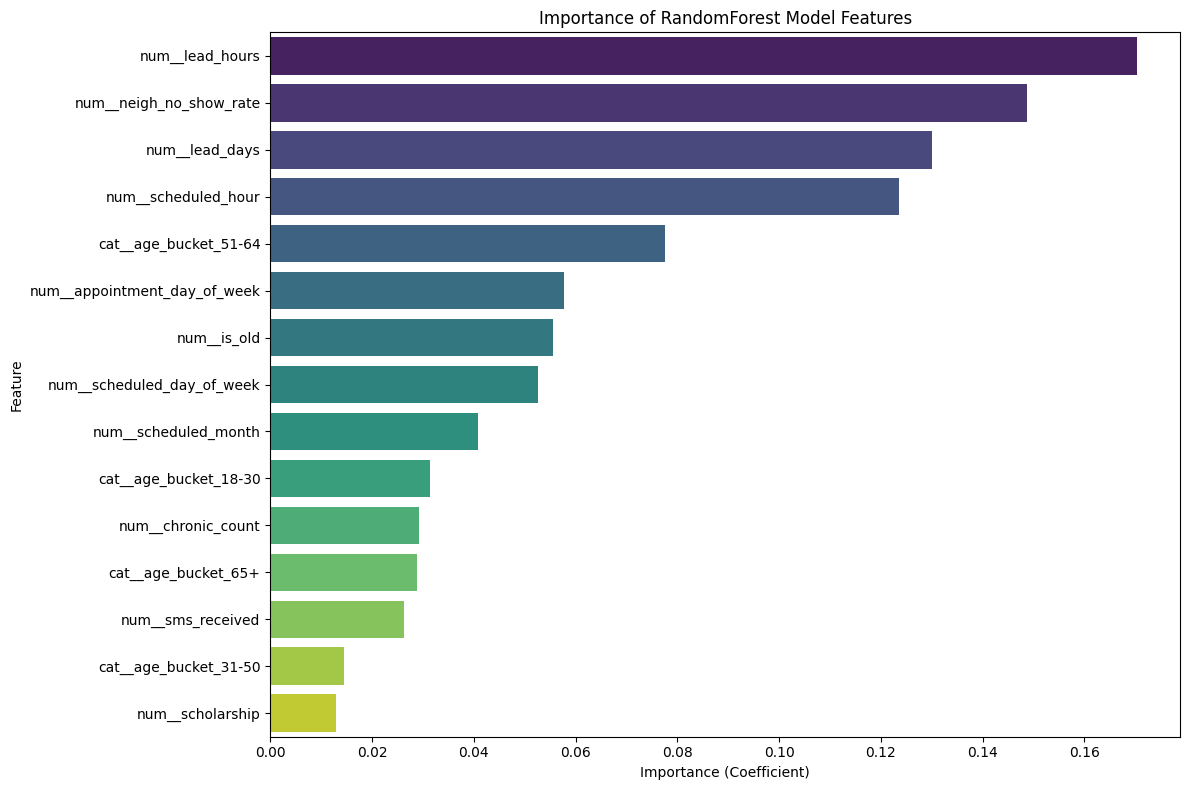

In [35]:
# Access the classifier step and extract the importances
feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

# Retrieve the names of the transformed features
feature_names = best_model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame combining names and importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by ‘Importance’ in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Use seaborn.barplot to create a bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importance of RandomForest Model Features')
plt.xlabel('Importance (Coefficient)')
plt.ylabel('Feature')
plt.tight_layout()

# 6. Display the graph
plt.show()

# 7) Exploring the XGBoost model

Evaluate whether a model based on Gradient Boosting (XGBoost) can achieve better metric results for the no-show class.


### Install of XGBoost



In [36]:
!pip install xgboost

### Import XGBoost and then define the 'objective_xgb' for Optuna optimization.



In [37]:
from xgboost import XGBClassifier

def objective_xgb(trial):    # again with the help of AI to find the best parameters and ranges
    # Hyperparameters for XGBClassifier
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)

    # Hyperparameters for SMOTE
    smote_sampling_strategy = trial.suggest_float('smote_sampling_strategy', 0.5, 1.0)
    smote_k_neighbors = trial.suggest_int('smote_k_neighbors', 3, 10)

    # Create an ImbPipeline with preprocessing, SMOTE, and XGBClassifier
    model_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42,
                        sampling_strategy=smote_sampling_strategy,
                        k_neighbors=smote_k_neighbors)),
        ('classifier', XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            use_label_encoder=False, # 'False' : sugested by the AI to remove an unnecessary warning
            eval_metric='logloss', # 'logloss' : again suggested by the AI to stabilizes learning and, once again, prevents the model from sending you warning messages
            scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]) # Handle class imbalance
        ))
    ])

    # Train the model
    model_pipeline.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_val = model_pipeline.predict(X_val)

    # Evaluate the model using f1_score
    score = f1_score(y_val, y_pred_val, pos_label=1)

    return score


### Run the Optuna study (n_trials=100)

Now that the objective function for XGBoost is defined, the next step is to create an Optuna study and run the optimization process for 100 trials to find the best hyperparameters for the XGBoost model with SMOTE.


In [38]:
study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_optimization', storage=None)
study_xgb.optimize(objective_xgb, n_trials=100)

print("Number of finished trials: ", len(study_xgb.trials))
print("Best trial (XGBoost):")
trial_xgb = study_xgb.best_trial

print("  Value: {}".format(trial_xgb.value))
print("  Params: ")
for key, value in trial_xgb.params.items():
    print("    {}: {}".format(key, value))

[I 2026-03-12 19:35:56,761] A new study created in memory with name: xgboost_optimization
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[19:36:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


[I 2026-03-12 19:36:05,301] Trial 0 finished with value: 0.4531640299750208 and parameters: {'n_estimators': 79, 'max_depth': 6, 'learning_rate': 0.23629936342163851, 'subsample': 0.9058988575660545, 'colsample_bytree': 0.804928623548454, 'smote_sampling_strategy': 0.7719715922994326, 'smote_k_neighbors': 3}. Best is trial 0 with value: 0.4531640299750208.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[19:36:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


[I 2026-03-12 19:36:17,261] Trial 1 finished with value: 0.4506329113924051 and parameters: {'n_estimators': 63, 'max_depth': 8, 'learning_rate': 0.03492296743999792

Number of finished trials:  100
Best trial (XGBoost):
  Value: 0.4619149587029673
  Params: 
    n_estimators: 89
    max_depth: 6
    learning_rate: 0.06372508743489633
    subsample: 0.8719816982310813
    colsample_bytree: 0.9788719881802372
    smote_sampling_strategy: 0.536968233314231
    smote_k_neighbors: 4


In [39]:
# Optimization history (F1 score per trial) for XGBoost
fig_history_xgb = ov.plot_optimization_history(study_xgb)
fig_history_xgb.update_layout(title='Importance of hyperparameters (XGBoost - F1 score optimization)')
fig_history_xgb

In [40]:
# Importance des hyperparamètres pour XGBoost
fig_importance_xgb = ov.plot_param_importances(study_xgb)
fig_importance_xgb.update_layout(title='Importance of hyperparameters (XGBoost)')
fig_importance_xgb

### Create and train the **final model** with the best hyperparameters and SMOTE using **XGBoost**

Creation of a final XGBoost model using these optimized parameters, integration of SMOTE, and training on the combined training and validation datasets.



In [41]:
best_params_xgb = study_xgb.best_trial.params

best_model_pipeline_xgb = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42,
                    sampling_strategy=best_params_xgb['smote_sampling_strategy'],
                    k_neighbors=best_params_xgb['smote_k_neighbors'])),
    ('classifier', XGBClassifier(
        n_estimators=best_params_xgb['n_estimators'],
        max_depth=best_params_xgb['max_depth'],
        learning_rate=best_params_xgb['learning_rate'],
        subsample=best_params_xgb['subsample'],
        colsample_bytree=best_params_xgb['colsample_bytree'],
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train_final.value_counts()[0] / y_train_final.value_counts()[1])
    ))
])

# Train the final model with the best parameters on the combined training and validation sets
best_model_pipeline_xgb.fit(X_train_final, y_train_final)

print("Final XGBoost model pipeline created and trained with best hyperparameters from Optuna.")
print(f"Best XGBoost hyperparameters: {best_params_xgb}")
print(f"Number of occurrences of each class in final training set: {y_train_final.value_counts()}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[19:41:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




Final XGBoost model pipeline created and trained with best hyperparameters from Optuna.
Best XGBoost hyperparameters: {'n_estimators': 89, 'max_depth': 6, 'learning_rate': 0.06372508743489633, 'subsample': 0.8719816982310813, 'colsample_bytree': 0.9788719881802372, 'smote_sampling_strategy': 0.536968233314231, 'smote_k_neighbors': 4}
Number of occurrences of each class in final training set: no_show
0    43719
1    17441
Name: count, dtype: int64


### Evaluation of the final optimized XGBoost model

In [42]:
# Predictions from the best XGBoost model on the test set
y_pred_xgb = best_model_pipeline_xgb.predict(X_test)

# Display the classification report
print("Rapport de classification pour le modèle XGBoost optimisé:")
print(classification_report(y_test, y_pred_xgb, target_names=['Show', 'No-Show']))

Rapport de classification pour le modèle XGBoost optimisé:
              precision    recall  f1-score   support

        Show       0.80      0.42      0.55      7716
     No-Show       0.34      0.73      0.46      3078

    accuracy                           0.51     10794
   macro avg       0.57      0.58      0.51     10794
weighted avg       0.66      0.51      0.53     10794



### Applying a new decision threshold to the XGBoost model

In [43]:
# Obtain the probabilities of the positive class (no-show) on the test set
y_pred_proba_xgb = best_model_pipeline_xgb.predict_proba(X_test)[:, 1]

# Set the new threshold
new_threshold_xgb = 0.3 # Use the same threshold for the initial comparison

# Apply the new threshold to obtain the new binary predictions
y_pred_xgb_new_threshold = (y_pred_proba_xgb >= new_threshold_xgb).astype(int)

# Evaluate the model with the new threshold
accuracy_new_xgb = accuracy_score(y_test, y_pred_xgb_new_threshold)
f1_new_xgb = f1_score(y_test, y_pred_xgb_new_threshold, average='binary', pos_label=1)
recall_new_xgb = recall_score(y_test, y_pred_xgb_new_threshold, pos_label=1)

print(f"New threshold: {new_threshold_xgb}")
print(f"Accuracy with new threshold: {accuracy_new_xgb:.4f}")
print(f"F1-score with new threshold: {f1_new_xgb:.4f}")
print(f"Recall with new threshold: {recall_new_xgb:.4f}")

New threshold: 0.3
Accuracy with new threshold: 0.2958
F1-score with new threshold: 0.4455
Recall with new threshold: 0.9922


# 8) Exploring the LightGBM model

This time, test another Gradient Boosting algorithm (LightGBM).

### install of 'Lightgbm' library



In [44]:
import sys
!{sys.executable} -m pip install lightgbm

### Import LightGBM and then define the 'objective_lgbm' for Optuna optimization




In [45]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):   # again with the help of AI to find the best parameters and ranges
    # Hyperparameters for LGBMClassifier
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)

    # Hyperparameters for SMOTE
    smote_sampling_strategy = trial.suggest_float('smote_sampling_strategy', 0.5, 1.0)
    smote_k_neighbors = trial.suggest_int('smote_k_neighbors', 3, 10)

    # Create an ImbPipeline with preprocessing, SMOTE, and LGBMClassifier
    model_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42,
                        sampling_strategy=smote_sampling_strategy,
                        k_neighbors=smote_k_neighbors)),
        ('classifier', LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Train the model
    model_pipeline.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_val = model_pipeline.predict(X_val)

    # Evaluate the model using f1_score
    score = f1_score(y_val, y_pred_val, pos_label=1)

    return score

## Run the Optuna study (n_trials=100)

Now that the objective function for LightGBM is defined, the next step is to create an Optuna study and run the optimization process for 100 trials to find the best hyperparameters for the LightGBM model with SMOTE.

In [46]:
study_lgbm = optuna.create_study(direction='maximize', study_name='lightgbm_optimization', storage=None)
study_lgbm.optimize(objective_lgbm, n_trials=100)

print("Number of finished trials: ", len(study_lgbm.trials))
print("Best trial (LightGBM):")
trial_lgbm = study_lgbm.best_trial

print("  Value: {}".format(trial_lgbm.value))
print("  Params: ")
for key, value in trial_lgbm.params.items():
    print("    {}: {}".format(key, value))

[I 2026-03-12 19:42:10,182] A new study created in memory with name: lightgbm_optimization


[LightGBM] [Info] Number of positive: 21669, number of negative: 36024
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2572
[LightGBM] [Info] Number of data points in the train set: 57693, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

[I 2026-03-12 19:42:19,738] Trial 0 finished with value: 0.37632286995515696 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.11786736815517776, 'subsample': 0.6542678702353457, 'colsample_bytree': 0.6566464927351007, 'smote_sampling_strategy': 0.6015296406700694, 'smote_k_neighbors': 6}. Best is trial 0 with value: 0.37632286995515696.


[LightGBM] [Info] Number of positive: 25388, number of negative: 36024
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2562
[LightGBM] [Info] Number of data points in the train set: 61412, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

[I 2026-03-12 19:42:30,565] Trial 1 finished with value: 0.3354480570975416 and parameters: {'n_estimators': 72, 'max_depth': 8, 'learning_rate': 0.2589217855954953, 'subsample': 0.8574822142460807, 'colsample_bytree': 0.7007141101698562, 'smote_sampling_strategy': 0.7047701335937232, 'smote_k_neighbors': 3}. Best is trial 0 with value: 0.37632286995515696.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 27362, number of negative: 36024
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2813
[LightGBM] [Info] Number of data points in the train set: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

[I 2026-03-12 19:48:09,099] Trial 98 finished with value: 0.38664859369705185 and parameters: {'n_estimators': 190, 'max_depth': 3, 'learning_rate': 0.04629016777792884, 'subsample': 0.7492611305149351, 'colsample_bytree': 0.7948325423101089, 'smote_sampling_strategy': 0.7595714546892602, 'smote_k_neighbors': 5}. Best is trial 56 with value: 0.44814573845152894.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 20906, number of negative: 36024
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2353
[LightGBM] [Info] Number of data points in the train set: 56930, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

[I 2026-03-12 19:48:12,110] Trial 99 finished with value: 0.39174900329346507 and parameters: {'n_estimators': 171, 'max_depth': 3, 'learning_rate': 0.20613826829628024, 'subsample': 0.7138665744450492, 'colsample_bytree': 0.8062403458266131, 'smote_sampling_strategy': 0.5803442489891275, 'smote_k_neighbors': 5}. Best is trial 56 with value: 0.44814573845152894.


Number of finished trials:  100
Best trial (LightGBM):
  Value: 0.44814573845152894
  Params: 
    n_estimators: 130
    max_depth: 3
    learning_rate: 0.04475230869407831
    subsample: 0.7536472243648287
    colsample_bytree: 0.8316575014444347
    smote_sampling_strategy: 0.5247701086539748
    smote_k_neighbors: 6


### Create and train the final model with the best hyperparameters and SMOTE using LightGBM

Creation of a final LightGBM model using these optimized parameters, integrate SMOTE, and train it on the combined training and validation datasets.



In [47]:
best_params_lgbm = study_lgbm.best_trial.params

best_model_pipeline_lgbm = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42,
                    sampling_strategy=best_params_lgbm['smote_sampling_strategy'],
                    k_neighbors=best_params_lgbm['smote_k_neighbors'])),
    ('classifier', LGBMClassifier(
        n_estimators=best_params_lgbm['n_estimators'],
        max_depth=best_params_lgbm['max_depth'],
        learning_rate=best_params_lgbm['learning_rate'],
        subsample=best_params_lgbm['subsample'],
        colsample_bytree=best_params_lgbm['colsample_bytree'],
        random_state=42,
        class_weight='balanced'
    ))
])

best_model_pipeline_lgbm.fit(X_train_final, y_train_final)

print("Final LightGBM model pipeline created and trained with best hyperparameters from Optuna.")
print(f"Best LightGBM hyperparameters: {best_params_lgbm}")
print(f"Number of occurrences of each class in final training set: {y_train_final.value_counts()}")

[LightGBM] [Info] Number of positive: 22942, number of negative: 43719
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2323
[LightGBM] [Info] Number of data points in the train set: 66661, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [48]:
# Optimization history (F1 score per trial) for LightGBM
fig_history_lgbm = ov.plot_optimization_history(study_lgbm)
fig_history_lgbm.update_layout(title='Historique d\'optimisation (LightGBM)')
fig_history_lgbm

In [49]:
# Optimization history (F1 score per trial) for LightGBM
fig_importance_lgbm = ov.plot_param_importances(study_lgbm)
fig_importance_lgbm.update_layout(title='Importance of hyperparameters (LightGBM)')
fig_importance_lgbm

### Evaluation of the performance of the final optimized LightGBM model

In [50]:
# Obtain predictions from the best LightGBM model on the test set
y_pred_lgbm = best_model_pipeline_lgbm.predict(X_test)

# Display the classification repor
print("Classification report for the optimized LightGBM model:")
print(classification_report(y_test, y_pred_lgbm, target_names=['Show', 'No-Show']))

Classification report for the optimized LightGBM model:
              precision    recall  f1-score   support

        Show       0.77      0.63      0.69      7716
     No-Show       0.36      0.53      0.43      3078

    accuracy                           0.60     10794
   macro avg       0.57      0.58      0.56     10794
weighted avg       0.65      0.60      0.62     10794



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



### Applying a new decision threshold to the LightGBM model

In [51]:
#  Obtain the probabilities of the positive class (no-show) on the test set
# Remove the UserWarning for LightGBM prediction
import warnings
with warnings.catch_warnings():      # 'with warnings.catch_warnings()' : used to temporarily ignore LightGBM warning messages (susggested by the AI)
    warnings.simplefilter("ignore", UserWarning)
    y_pred_proba_lgbm = best_model_pipeline_lgbm.predict_proba(X_test)[:, 1]

# Define the new threshold
new_threshold_lgbm = 0.3 # Again, using the same threshold for the initial comparison

# Apply the new threshold to obtain the new binary predictions
y_pred_lgbm_new_threshold = (y_pred_proba_lgbm >= new_threshold_lgbm).astype(int)

# Evaluate the model with the new threshold
accuracy_new_lgbm = accuracy_score(y_test, y_pred_lgbm_new_threshold)
f1_new_lgbm = f1_score(y_test, y_pred_lgbm_new_threshold, average='binary', pos_label=1)
recall_new_lgbm = recall_score(y_test, y_pred_lgbm_new_threshold, pos_label=1)

print(f"New threshold: {new_threshold_lgbm}")
print(f"Accuracy with new threshold: {accuracy_new_lgbm:.4f}")
print(f"F1-score with new threshold: {f1_new_lgbm:.4f}")
print(f"Recall with new threshold: {recall_new_lgbm:.4f}")

New threshold: 0.3
Accuracy with new threshold: 0.2977
F1-score with new threshold: 0.4466
Recall with new threshold: 0.9938




---


## 9) Compare Models


---



Compare the scores of the models for the "No-Show" class based on the classification reports for each model (RandomForest, XGBoost, LightGBM)

In [52]:
# Get predictions for all models
y_pred_rf = best_model_pipeline.predict(X_test)
y_pred_xgb = best_model_pipeline_xgb.predict(X_test)
#  import warnings : to temporarily remove the warning for LightGBM (suggested by AI to avoid displaying unnecessary warning messages)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
y_pred_lgbm = best_model_pipeline_lgbm.predict(X_test)

# Generate classification reports
report_rf = classification_report(y_test, y_pred_rf, target_names=['Show', 'No-Show'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Show', 'No-Show'], output_dict=True)
report_lgbm = classification_report(y_test, y_pred_lgbm, target_names=['Show', 'No-Show'], output_dict=True)

# Extract F1-score, Recall for 'No-Show' and overall accuracy
f1_rf = report_rf['No-Show']['f1-score']
recall_rf = report_rf['No-Show']['recall']
accuracy_rf = report_rf['accuracy']
f1_xgb = report_xgb['No-Show']['f1-score']
recall_xgb = report_xgb['No-Show']['recall']
accuracy_xgb = report_xgb['accuracy']
f1_lgbm = report_lgbm['No-Show']['f1-score']
recall_lgbm = report_lgbm['No-Show']['recall']
accuracy_lgbm = report_lgbm['accuracy']

print("Extracted Metrics:")
print(f"RandomForest - F1-score (No-Show): {f1_rf:.4f}, Recall (No-Show): {recall_rf:.4f}, Accuracy: {accuracy_rf:.4f}")
print(f"XGBoost - F1-score (No-Show): {f1_xgb:.4f}, Recall (No-Show): {recall_xgb:.4f}, Accuracy: {accuracy_xgb:.4f}")
print(f"LightGBM - F1-score (No-Show): {f1_lgbm:.4f}, Recall (No-Show): {recall_lgbm:.4f}, Accuracy: {accuracy_lgbm:.4f}")

Extracted Metrics:
RandomForest - F1-score (No-Show): 0.4324, Recall (No-Show): 0.5224, Accuracy: 0.6089
XGBoost - F1-score (No-Show): 0.4588, Recall (No-Show): 0.7274, Accuracy: 0.5107
LightGBM - F1-score (No-Show): 0.4301, Recall (No-Show): 0.5309, Accuracy: 0.5989


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

